# 13 - air drag: terminal velocity, the Skimmer's parachute, and the bullet that misses

Two earlier results are waiting on air. Notebook 10 showed iron feruchemy
working as a brake but left canon Skimmer safe-falling open, because in a
vacuum a light body falls exactly as fast as a heavy one. Notebooks 12 and
12B ended with bullets leaving bubble boundaries slowed and tumbling, and
noted that tumbling only matters to the flight path if there is air to
grab the tumble. This notebook adds the air: `sim/air.py`.

Terms used in this notebook, defined once:

- **Drag**: the push of air against motion, growing with the square of
  speed. Force = 0.5 * air_density * drag_coefficient * area * speed^2,
  pointed against the velocity.
- **Drag coefficient**: how much the air grips a shape. 0.47 for a sphere
  (the default on every body), about 1.0 for a person falling flat.
- **Terminal velocity**: the speed where drag balances weight and a
  falling body stops accelerating:
  sqrt(2 * m * g / (air_density * drag_coefficient * area)). It grows
  with the square root of mass - which is the entire Skimmer story.
- **Relaxation length**: the distance of travel drag needs to mostly
  adjust a body's speed: 2 * m / (air_density * drag_coefficient * area).
  A body changes speed over a few of these, not instantly.
- **Miss distance**, **tilt**, **spin**: as in notebooks 12 and 12B (how
  far the flight line misses the bubble's center; the angle between a
  body's long axis and its motion; rotation rate in deg/s).

Model choices, stated: drag is quadratic (the right form for fast
objects; slow syrupy drag is for dust motes), the cross-section of a
point mass is a sphere of its ground-contact radius, the air is still and
uniformly dense, and the air inside a bubble shares the bubble's time -
drag is computed from stored velocity and integrated over local time like
every other force. Consequence of that last choice, probe-checked: a
faller inside a 5x bubble lands in a fifth of the outside time but at the
same speed. Air is opt-in: nothing feels it until an AirDrag power is
added, so every earlier notebook and probe is untouched.

No spring ground truth in this notebook: drag is a plain force with exact
paper answers (the terminal-velocity formula), so the formula is the
check. Probes pin it: `check_terminal_velocity_matches_paper`,
`check_lighter_bodies_fall_slower`,
`check_bubbled_faller_lands_sooner_not_harder`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import (Body, World, SpeedBubble, RigidFrame, AirDrag,
                 IronFeruchemy, AIR_DENSITY_KG_PER_M3, GRAVITY_M_PER_S2)


def terminal_velocity(mass_kg, radius_m, drag_coefficient):
    area = np.pi * radius_m ** 2
    return np.sqrt(2 * mass_kg * GRAVITY_M_PER_S2
                   / (AIR_DENSITY_KG_PER_M3 * drag_coefficient * area))


def relaxation_length(mass_kg, radius_m, drag_coefficient):
    area = np.pi * radius_m ** 2
    return 2 * mass_kg / (AIR_DENSITY_KG_PER_M3 * drag_coefficient * area)


class AntiGravity:
    """Cancels gravity. Used only in experiment C, so the bullet's path
    bends are the bubble's and the air's doing, not gravity's."""

    def __init__(self, bodies):
        self.bodies = bodies

    def apply_forces(self):
        for body in self.bodies:
            body.apply_force([0.0, GRAVITY_M_PER_S2 * body.mass_kg])

## Experiment A - terminal velocity against the formula

Drop spheres of different masses (same size) and let them settle. Paper
prediction: each lands on the terminal-velocity formula, so doubling the
mass four times over should exactly double the falling speed twice over.

 mass kg   measured m/s   paper m/s
    0.25          16.46       16.47
    0.50          23.28       23.29
    1.00          32.93       32.93
    2.00          46.57       46.58
    4.00          65.85       65.87


    8.00          93.13       93.15


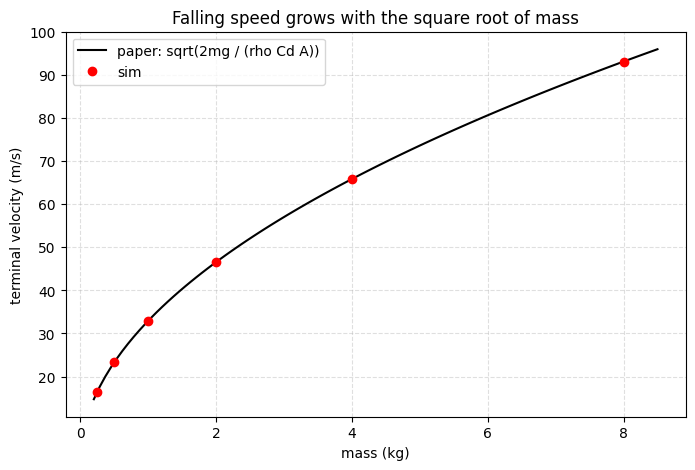

In [2]:
masses = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
measured = []
print(f"{'mass kg':>8}  {'measured m/s':>13}  {'paper m/s':>10}")
for mass in masses:
    world = World()
    expected = terminal_velocity(mass, 0.1, 0.47)
    # Settling takes about 4.5 * v/g seconds and covers about 3.8 * v^2/g
    # meters of fall, so 5 * v^2/g of height leaves margin to stay airborne.
    settle_seconds = 4.5 * expected / GRAVITY_M_PER_S2
    drop_height_m = 5.0 * expected ** 2 / GRAVITY_M_PER_S2
    ball = world.add_body(Body("ball", mass, (0, drop_height_m), radius_m=0.1))
    world.add_power(AirDrag(world))
    world.run(settle_seconds)
    assert not ball.on_ground, "ball must still be airborne when measured"
    measured.append(-ball.velocity[1])
    print(f"{mass:8.2f}  {measured[-1]:13.2f}  {expected:10.2f}")

curve_masses = np.linspace(0.2, 8.5, 100)
plt.figure(figsize=(8, 5))
plt.plot(curve_masses, [terminal_velocity(m, 0.1, 0.47) for m in curve_masses],
         "k-", label="paper: sqrt(2mg / (rho Cd A))")
plt.plot(masses, measured, "ro", label="sim")
plt.xlabel("mass (kg)")
plt.ylabel("terminal velocity (m/s)")
plt.title("Falling speed grows with the square root of mass")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Experiment B - the Skimmer's parachute

A Skimmer stores weight to fall slowly: less mass, lower terminal
velocity. With air in the engine this should finally emerge. But there is
a trap hiding in notebook 03's founding result: storing mass conserves
momentum, so the moment Wax stores three quarters of his weight, his
speed JUMPS four-fold. Drag then has to haul him back down, and drag
needs distance to work - a few relaxation lengths. Wax at quarter weight
(20 kg, falling flat, drag coefficient 1.0) has a relaxation length of
115 m.

Paper prediction: storing is a parachute only if done high. Stored high,
Wax lands at half his normal landing speed (terminal velocity scales with
sqrt(mass), and sqrt(1/4) = 1/2). Stored low, he hits the ground mid-jump,
moving FASTER than if he had never stored at all. Somewhere in between is
a break-even altitude, expected at one to two relaxation lengths.

One knob: the altitude at which he stores. Fraction fixed at 75%, drop
from 800 m, the storing done by the ordinary IronFeruchemy component -
no special cases, per the founding rule.

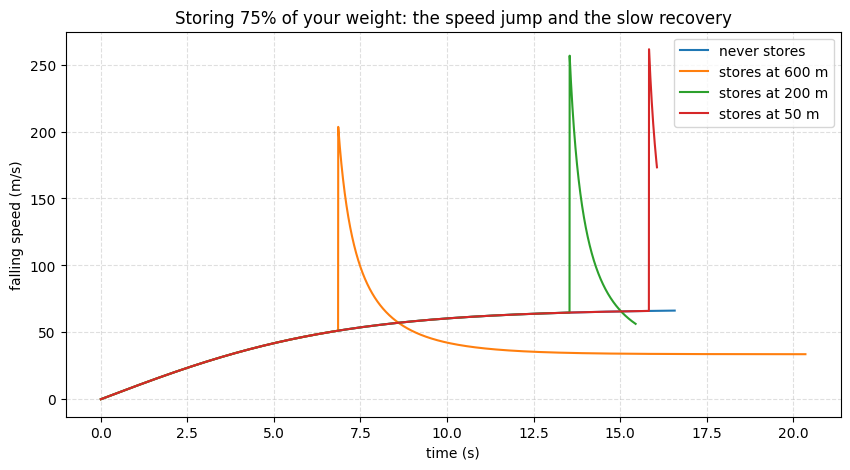

never stores: lands at 66.3 m/s
 store at (m)   landing speed m/s
          600                33.7
          500                33.8
          400                34.5
          300                38.4
          250                44.4
          200                56.4


          150                77.9   <- worse than never storing
          100               114.3   <- worse than never storing
           50               173.3   <- worse than never storing
           25               215.7   <- worse than never storing


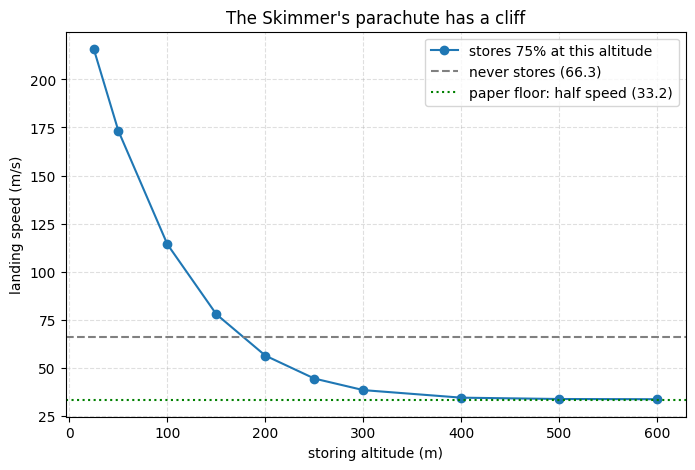

In [3]:
def skimmer_fall(store_altitude_m, store_fraction=0.75, drop_from_m=800.0):
    """Drop Wax, store weight when he passes the given altitude, return
    (landing speed, full speed history). store_altitude_m=None: never store."""
    world = World()
    wax = world.add_body(Body("wax", 80, (0, drop_from_m), drag_coefficient=1.0))
    ironmind = world.add_power(IronFeruchemy(wax))
    world.add_power(AirDrag(world))
    stored = False
    for _ in range(int(60 / world.dt_seconds)):
        world.step()
        if (not stored and store_altitude_m is not None
                and wax.position[1] <= store_altitude_m):
            ironmind.store(store_fraction)
            stored = True
        if wax.on_ground:
            break
    data = world.history.body("wax")
    landing_speed = -data["vy"][np.argmax(data["on_ground"]) - 1]
    return landing_speed, data


# The shape of the fall, three storing altitudes against never storing.
plt.figure(figsize=(10, 5))
for altitude, label in [(None, "never stores"), (600, "stores at 600 m"),
                        (200, "stores at 200 m"), (50, "stores at 50 m")]:
    landing, data = skimmer_fall(altitude)
    airborne = ~data["on_ground"].astype(bool)
    plt.plot(data["t"][airborne], -data["vy"][airborne], label=label)
plt.xlabel("time (s)")
plt.ylabel("falling speed (m/s)")
plt.title("Storing 75% of your weight: the speed jump and the slow recovery")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

baseline, _ = skimmer_fall(None)
print(f"never stores: lands at {baseline:.1f} m/s")
print(f"{'store at (m)':>13}  {'landing speed m/s':>18}")
altitudes = [600, 500, 400, 300, 250, 200, 150, 100, 50, 25]
landings = []
for altitude in altitudes:
    landing, _ = skimmer_fall(altitude)
    landings.append(landing)
    note = "   <- worse than never storing" if landing > baseline else ""
    print(f"{altitude:13d}  {landing:18.1f}{note}")

plt.figure(figsize=(8, 5))
plt.plot(altitudes, landings, "o-", label="stores 75% at this altitude")
plt.axhline(baseline, color="gray", linestyle="--", label="never stores (66.3)")
plt.axhline(baseline / 2, color="green", linestyle=":",
            label="paper floor: half speed (33.2)")
plt.xlabel("storing altitude (m)")
plt.ylabel("landing speed (m/s)")
plt.title("The Skimmer's parachute has a cliff")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Reading the sweep:

- Stored at 600 m, Wax lands at 33.7 m/s - the paper's half-speed floor,
  reached. Stored at 100 m he lands at about 114 m/s, nearly twice as
  fast as if he had never touched his metalmind. The break-even sits
  around 180 m, about one and a half relaxation lengths.
- So feruchemal iron has two opposite fall disciplines, and they point in
  opposite directions. Notebook 10's brake (tapping weight to dump energy
  into the ground) must be done LATE, at the last moment. The parachute
  (storing weight so the air holds you) must be done EARLY, with hundreds
  of meters of sky in hand. A Skimmer who mixes up the two dies in either
  direction.
- Canon check: Wax's safe-falls in the books are long drops where he
  stores on the way down, not at the ground - consistent. The speed jump
  on storing comes straight from notebook 03's momentum rule biting back;
  nothing here was coded for the Skimmer.

## Experiment C - the bullet finally misses

Notebook 12B left a wide bullet leaving the bubble slowed and spinning at
thousands of deg/s, with its path bent by the boundary - but in vacuum, a
tumbling bullet still travels in a straight line. The claim to test:
drag is what converts tumble into path change.

Setup: the 20 cm x 5 cm four-point bullet from notebook 12B, fired at
50 m/s at a target plane 40 m away, crossing the standard 5x bubble at
miss distance 2. Gravity is cancelled so every path bend belongs to the
bubble or the air. Paper predictions: with air and no bubble, the bullet
flies dead straight (drag points against motion, and a non-spinning
bullet gives it no sideways grip) and arrives at 41.7 m/s (its corners'
relaxation length is 221 m, and 50 * exp(-40/221) = 41.7). With the
bubble, the bullet tumbles; whether air then changes its path, and by how
much, the run decides.

In [4]:
def fire(miss_distance_m, bubble, air, hz=4000, target_x=40.0):
    """Fire the wide bullet at the target plane; return (arrival height
    relative to the aim line, arrival speed, arrival spin)."""
    world = World(dt_seconds=1.0 / hz)
    aim_y = 10.0 + miss_distance_m
    spots = [(0.1, aim_y), (-0.1, aim_y), (0.0, aim_y + 0.025), (0.0, aim_y - 0.025)]
    bodies = [world.add_body(Body(f"corner{i}", 0.005, spot,
                                  velocity=(50, 0), radius_m=0.005))
              for i, spot in enumerate(spots)]
    world.add_power(RigidFrame(bodies))
    world.add_power(AntiGravity(bodies))
    if bubble:
        world.add_bubble(SpeedBubble(center=(10, 10), radius_m=5, time_factor=5.0))
    if air:
        world.add_power(AirDrag(world))
    for _ in range(int(8 * hz)):
        world.step()
        center = sum(body.position for body in bodies) / 4
        if center[0] >= target_x:
            break
    else:
        raise RuntimeError("bullet never reached the target plane")
    velocity = sum(body.velocity for body in bodies) / 4
    nose, tail = bodies[0], bodies[1]
    axis = nose.position - tail.position
    axis = axis / np.linalg.norm(axis)
    relative = nose.velocity - tail.velocity
    tangential = relative - np.dot(relative, axis) * axis
    spin = np.degrees(np.linalg.norm(tangential) / 0.2)
    return center[1] - aim_y, float(np.linalg.norm(velocity)), spin

print("wide bullet to a target plane 40 m out, aim at miss distance 2:")
print(f"{'setup':<14}  {'off aim':>9}  {'speed':>9}  {'spin':>10}")
for label, bubble, air in [("nothing", False, False), ("air only", False, True),
                           ("bubble only", True, False), ("bubble + air", True, True)]:
    off_aim, speed, spin = fire(2.0, bubble, air)
    print(f"{label:<14}  {off_aim:+8.3f} m  {speed:5.1f} m/s  {spin:6.0f} deg/s")

print()
print("aim sensitivity: shift the aim by centimeters, watch the arrival:")
for label, air in [("bubble only", False), ("bubble + air", True)]:
    arrivals = [fire(miss, True, air)[0] for miss in [1.90, 1.95, 2.00, 2.05, 2.10]]
    spread = max(arrivals) - min(arrivals)
    heights = " ".join(f"{a:+.2f}" for a in arrivals)
    print(f"  {label:<13}: arrival heights {heights} m -> spread {spread:.2f} m")

wide bullet to a target plane 40 m out, aim at miss distance 2:
setup             off aim      speed        spin


nothing           +0.000 m   50.0 m/s       0 deg/s


air only          +0.000 m   41.7 m/s       0 deg/s


bubble only       -2.278 m   14.4 m/s    1770 deg/s


bubble + air      -0.125 m   12.9 m/s    1812 deg/s

aim sensitivity: shift the aim by centimeters, watch the arrival:


  bubble only  : arrival heights -1.38 -1.29 -2.28 -0.10 -1.43 m -> spread 2.18 m


  bubble + air : arrival heights -1.11 -1.17 -0.12 +0.03 -0.85 m -> spread 1.20 m


Reading the table: the clean bullet through air flies dead straight and
arrives at 41.7 m/s, exactly the relaxation-length prediction. The same
shot through the bubble arrives meters off the aim line, tumbling - and
turning the air on moves the arrival point by about two meters relative
to the airless run. Air grips a tumbling bullet and not a clean one,
which was the claim.

## Findings

1. **Terminal velocity matches the paper formula across a 32x mass
   range.** Lighter bodies fall slower as sqrt(mass) - the Skimmer
   premise, now real (probe-checked).
2. **The Skimmer's parachute has a cliff.** Storing 75% of weight at
   600 m lands Wax at 33.7 m/s, half his normal landing speed. Storing at
   100 m lands him at 114 m/s, nearly double - because storing jumps his
   speed four-fold first (notebook 03's momentum rule) and drag needs a
   few 115 m relaxation lengths to recover. Break-even near 180 m. Iron's
   two fall disciplines point opposite ways: brake late (notebook 10),
   parachute early (this one).
3. **The bullet finally misses.** Through a bubble at 40 m range, a 20 cm
   change of aim scatters the arrival point by about 2 m, air or no air -
   aiming through a bubble is hopeless, as the books say. Air on its own
   adds nothing to a clean shot (dead straight, speed as predicted) but
   moves a tumbling bullet's arrival by meters: the boundary supplies the
   spin, the air converts spin into path change.
4. **What this air does not do, stated for the record:** drag-only air
   has no lift and no spin-induced sideways force (the Magnus effect, the
   curve of a spinning ball), so it did not widen the arrival scatter in
   the aim-sensitivity test. If a future notebook needs spinning bodies
   to curve, that is the missing piece, and it is a refinement of
   sim/air.py, not a rework.
5. A faller inside a 5x bubble lands in a fifth of the outside time at
   the same speed (probe-checked): the air shares the bubble's clock, as
   chosen and stated in sim/air.py.

Probe suite: 33 checks. Next: notebook 14 - portable anchors (pushing
off a moving bullet: the near-teleport idea against the momentum ledger).